In [1]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage import data

os.makedirs("images", exist_ok=True)
image_path = "images/Parrot.png"

if not os.path.exists(image_path):
  sample_img = data.coffee()
  sample_img_bgr = cv2.cvtColor(sample_img, cv2.COLOR_RGB2BGR)
  cv2.imwrite(image_path, sample_img_bgr)

image = cv2.imread(image_path)

if image is None:
  raise FileNotFoundError(
      f"Could not load image at '{image_path}'. Please verify the file exists."
  )

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

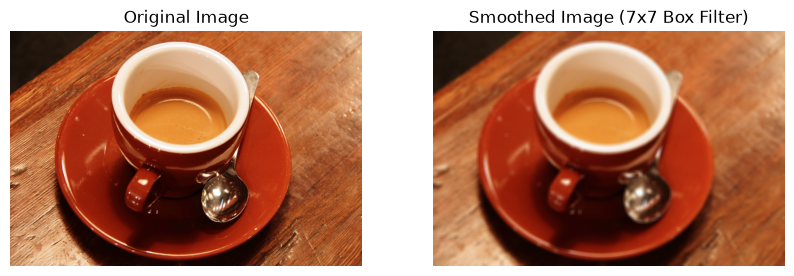

In [2]:
kernel_size = 7
box_kernel = np.ones((kernel_size, kernel_size), dtype=np.float32) / (
    kernel_size * kernel_size
)
smoothed_box = cv2.filter2D(image, -1, box_kernel)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(smoothed_box)
ax[1].set_title(f"Smoothed Image ({kernel_size}x{kernel_size} Box Filter)")
ax[1].axis("off")
plt.show()

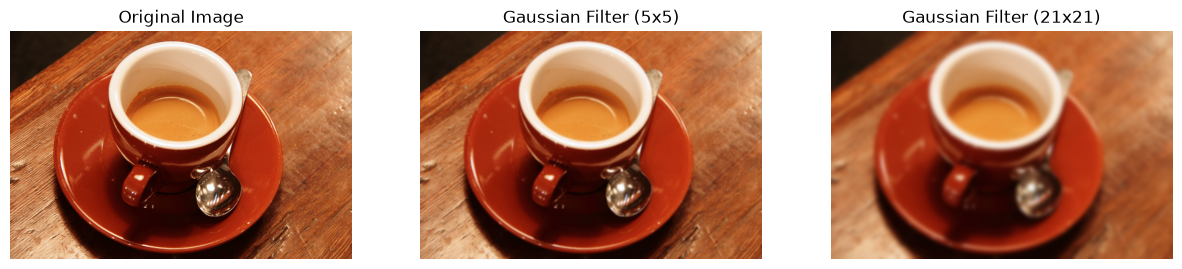

In [3]:
gaussian_5x5 = cv2.GaussianBlur(image, (5, 5), sigmaX=0, sigmaY=0)
gaussian_21x21 = cv2.GaussianBlur(image, (21, 21), sigmaX=0, sigmaY=0)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(gaussian_5x5)
ax[1].set_title("Gaussian Filter (5x5)")
ax[1].axis("off")

ax[2].imshow(gaussian_21x21)
ax[2].set_title("Gaussian Filter (21x21)")
ax[2].axis("off")
plt.show()

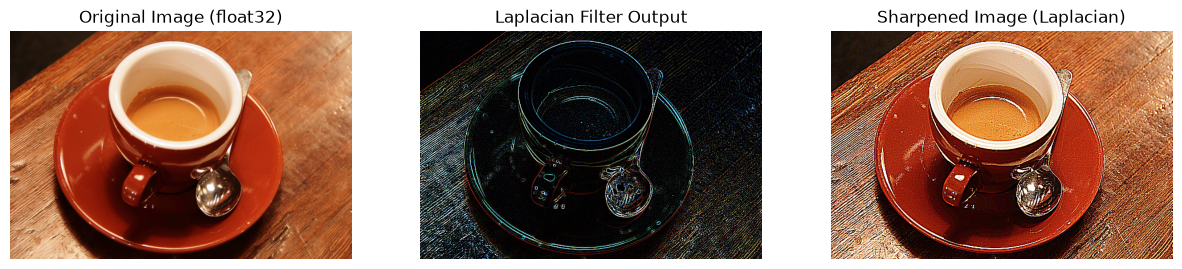

In [4]:
image_float = image.astype(np.float32) / 255.0
laplacian = cv2.Laplacian(image_float, cv2.CV_32F, ksize=3)
sharpened_laplacian = np.clip(image_float - laplacian, 0, 1)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image_float)
ax[0].set_title("Original Image (float32)")
ax[0].axis("off")

ax[1].imshow(np.clip(laplacian, 0, 1))
ax[1].set_title("Laplacian Filter Output")
ax[1].axis("off")

ax[2].imshow(sharpened_laplacian)
ax[2].set_title("Sharpened Image (Laplacian)")
ax[2].axis("off")
plt.show()